<a href="https://colab.research.google.com/github/tpiedrahita-byte/sys2025/blob/main/Varianza_Rayleigh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RECONSTRUCCIÓN MEJORADA DE PSD CON MEZCLAS GAUSSIANAS
Modelo 1 (varianza constante): K = 60, error relativo = 0.099953, criterio = se alcanzó el umbral
Modelo 2 (varianza Rayleigh):  K = 44, error relativo = 0.099894, criterio = se alcanzó el umbral
Modelo 3 (varianza normal):    K = 25, error relativo = 0.099814, criterio = se alcanzó el umbral


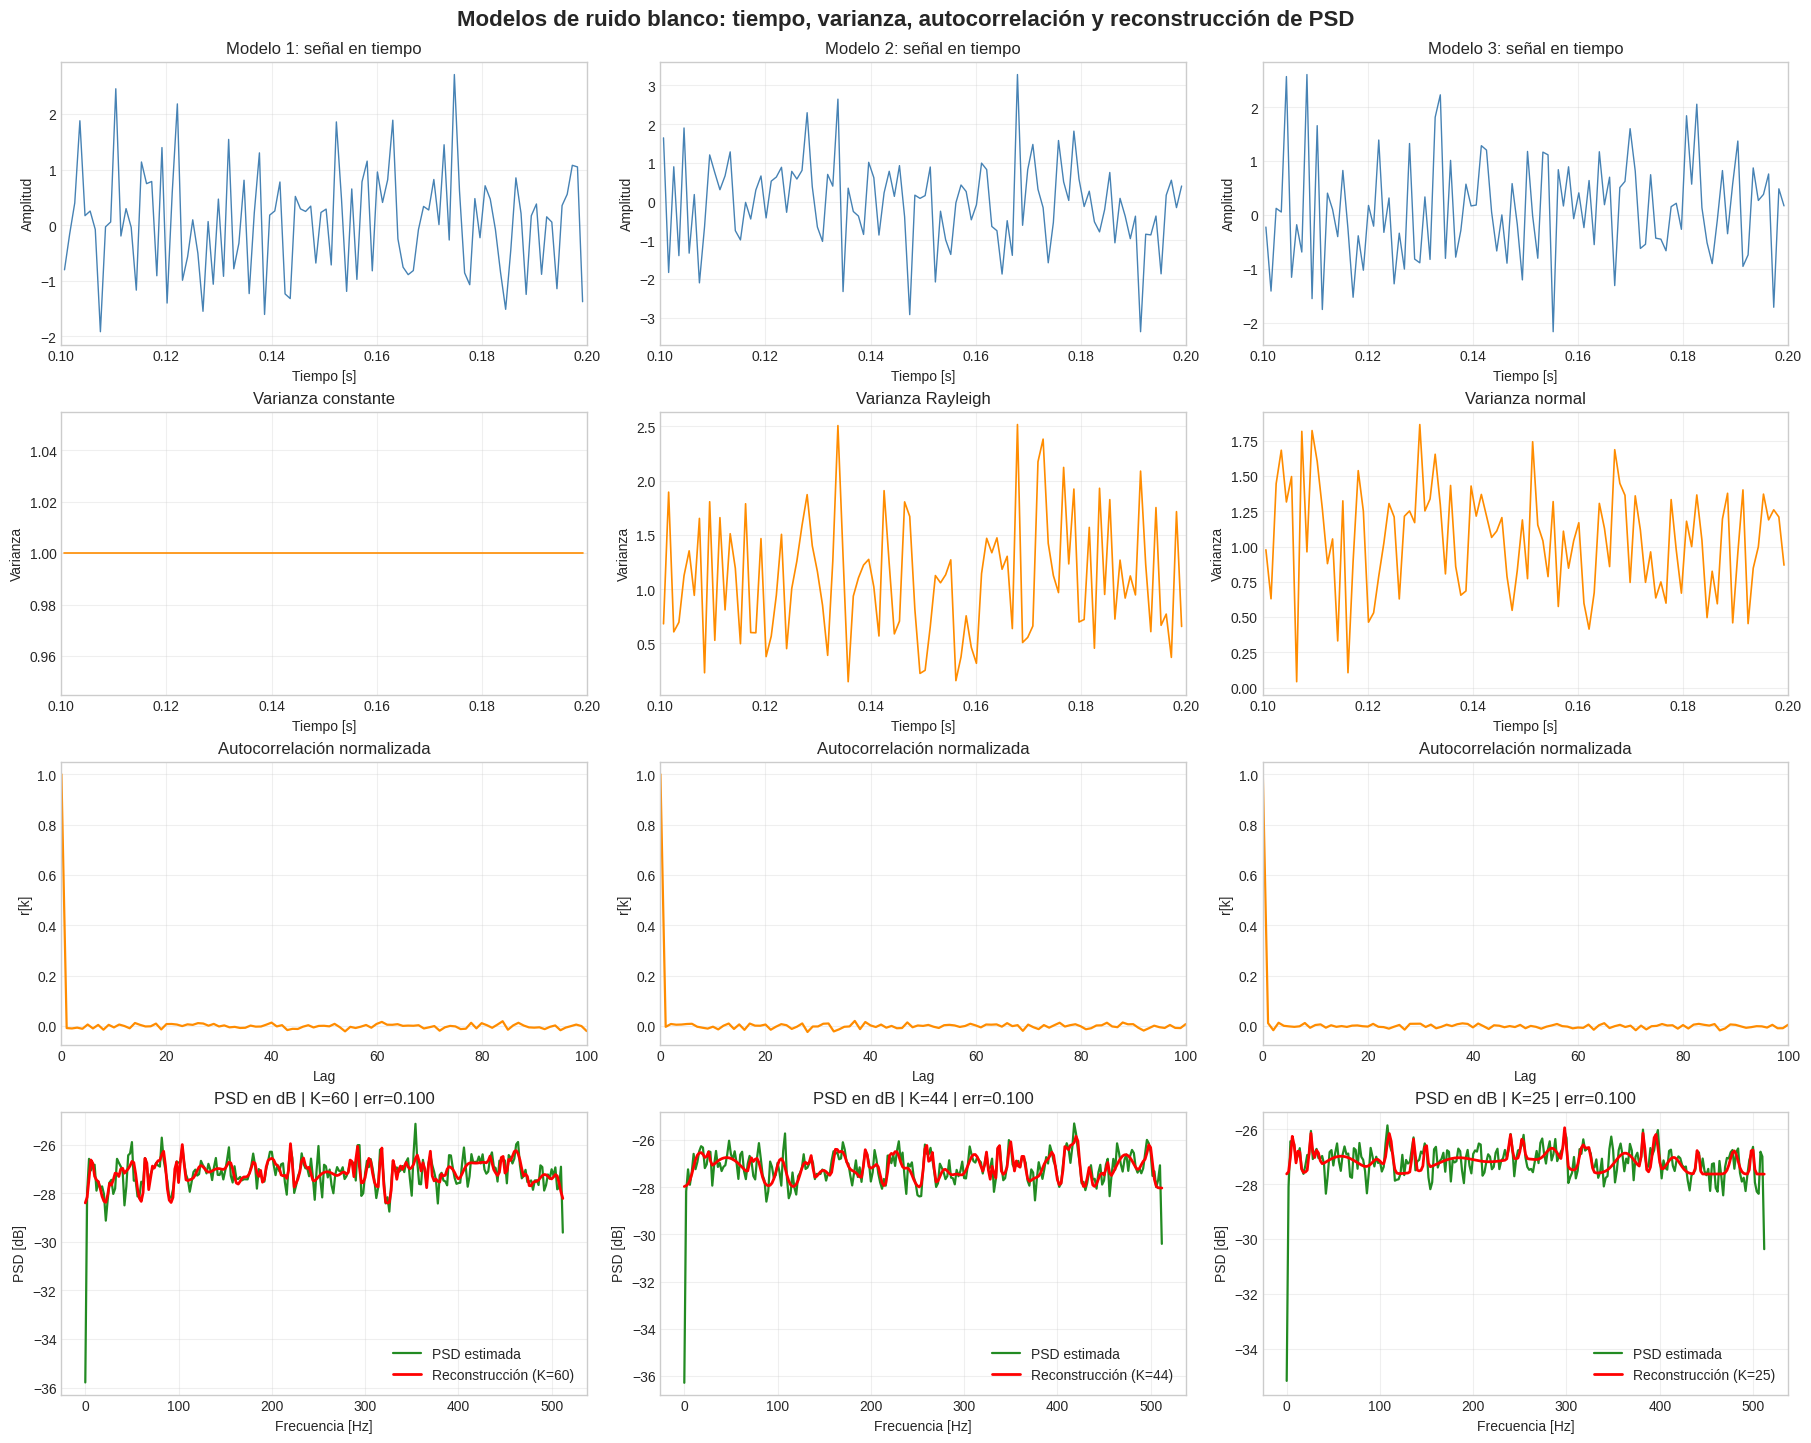

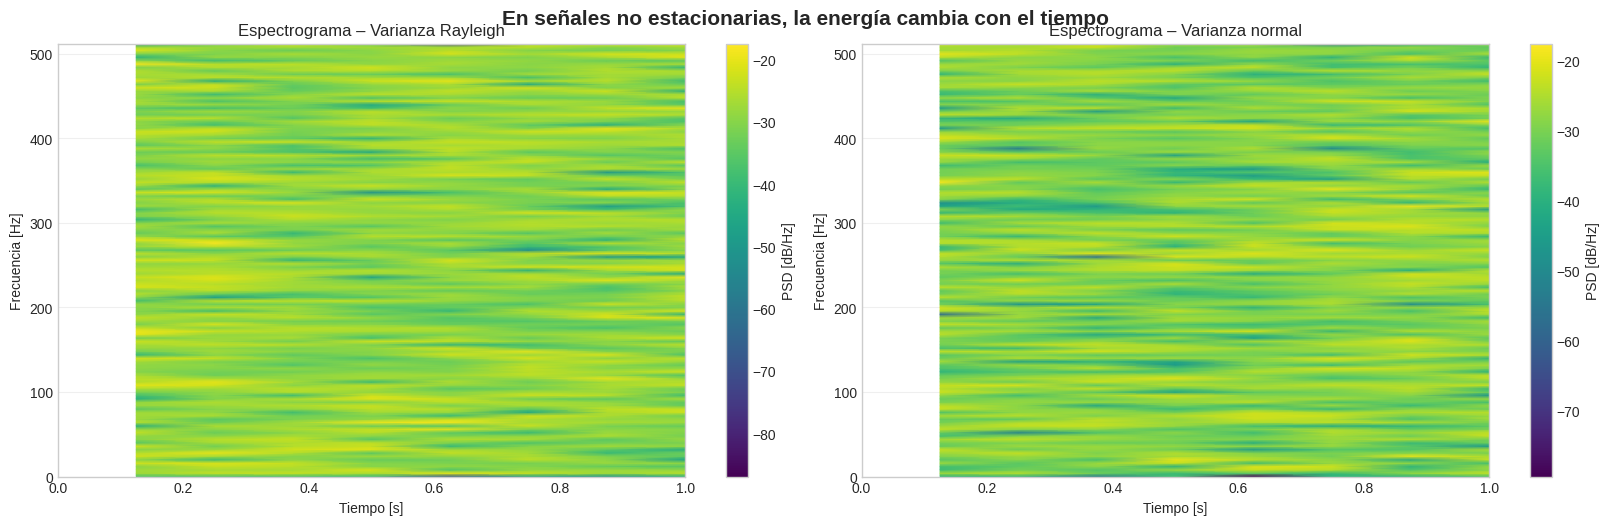

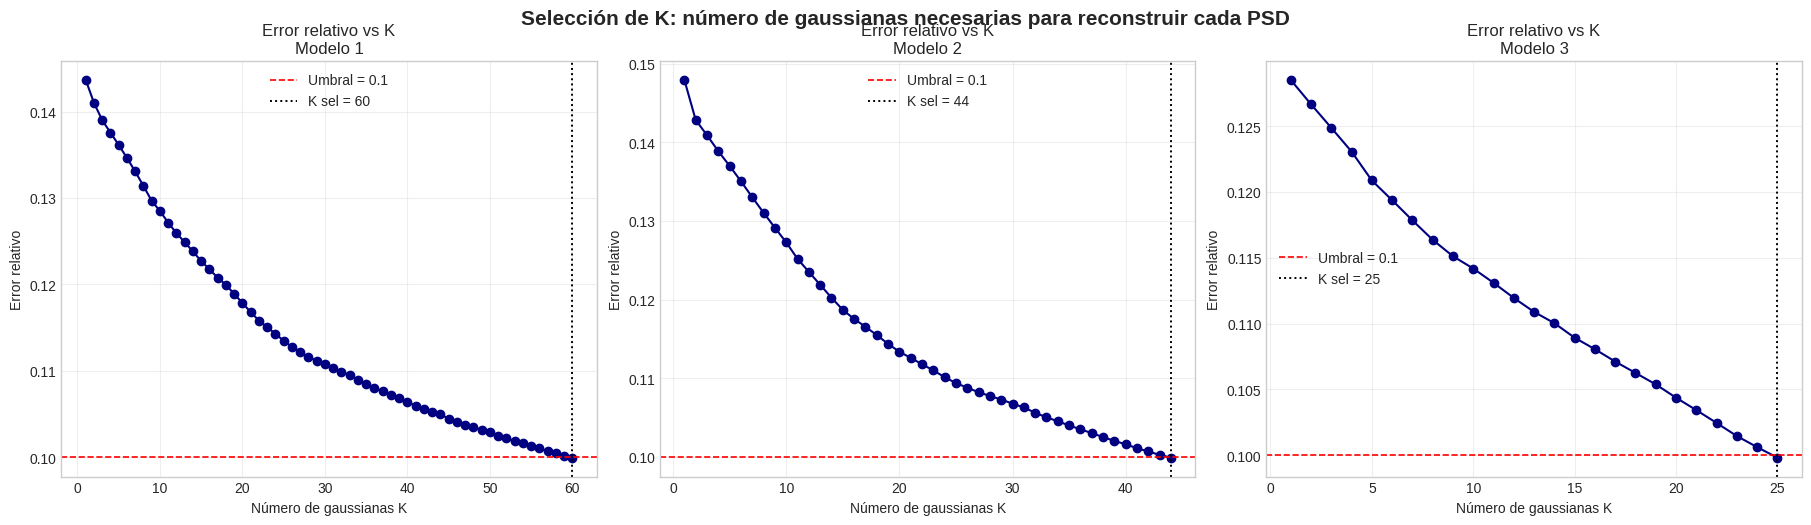


TABLA COMPARATIVA FINAL

Modelo           | Estacionario  | Tipo de varianza     | K seleccionado | Error relativo | Lectura principal
----------------------------------------------------------------------------------------------------------------------------------
Modelo 1         | Sí            | Constante            | 60             | 0.099953       | PSD global representativa
Modelo 2         | No            | Rayleigh             | 44             | 0.099894       | PSD promedio + espectrograma
Modelo 3         | No            | Normal               | 25             | 0.099814       | PSD promedio + espectrograma

IDEAS CLAVE

1. En el caso estacionario, la PSD promedio describe razonablemente bien toda la señal.
   Por eso el número de gaussianas K se interpreta directamente como complejidad espectral global.

2. En los casos no estacionarios, la varianza cambia con el tiempo.
   Entonces la PSD calculada con Welch sigue siendo útil, pero representa un promedio temporal.

3. Por

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, spectrogram
from scipy.optimize import nnls

# ============================================================================
# GENERALIZACIÓN DE LA RECONSTRUCCIÓN DE PSD CON MEZCLAS GAUSSIANAS
# Casos:
#   1) Ruido blanco estacionario con varianza constante
#   2) Ruido blanco no estacionario con varianza Rayleigh
#   3) Ruido blanco no estacionario con varianza normal
# ============================================================================

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# ------------------------------------------------------------
# PARÁMETROS GENERALES
# ------------------------------------------------------------
np.random.seed(42)

N = 16384
fs = 1024
t = np.arange(N) / fs

t_ini = 0.10
t_fin = 0.20
mask_t = (t >= t_ini) & (t <= t_fin)

mu_ruido = 0.0
varianza_objetivo = 1.0
sigma_const = np.sqrt(varianza_objetivo)

rayleigh_scale = 0.25
normal_mean_var = 1.0
normal_std_var = 0.35

nperseg_spec = 256
noverlap_spec = 128

K_MAX = 80
NUM_CENTROS = 80
NUM_SIGMAS = 28
SIGMA_MIN = 1.5
SIGMA_MAX = 260.0

UMBRAL_ERROR_RELATIVO = 0.10
MAX_LAG_ACF = 100

# ------------------------------------------------------------
# FUNCIONES AUXILIARES
# ------------------------------------------------------------
def ajustar_media_varianza(x, media=0.0, varianza=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    std = np.std(x)
    if std < 1e-12:
        raise ValueError("La desviación estándar es demasiado pequeña para normalizar.")
    return x / std * np.sqrt(varianza) + media

def autocorrelacion_normalizada_positiva(x, max_lag=100):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    r = np.correlate(x, x, mode='full')
    centro = len(r) // 2
    r = r[centro:centro + max_lag + 1]
    r = r / (r[0] + 1e-14)
    lags = np.arange(len(r))
    return lags, r

def estimar_psd(x, fs, nperseg=512):
    f, pxx = welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann',
        detrend='constant',
        scaling='density',
        return_onesided=True
    )
    return f, pxx

def gaussiana_1d(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def construir_diccionario_gaussiano(frecuencias, num_centros=80, num_sigmas=28, sigma_min=1.5, sigma_max=260.0):
    fmax = np.max(frecuencias)
    centros = np.linspace(0.0, fmax, num_centros)
    sigmas = np.geomspace(sigma_min, sigma_max, num_sigmas)

    columnas = []
    parametros = []

    for mu in centros:
        for sigma in sigmas:
            g = gaussiana_1d(frecuencias, mu, sigma)
            columnas.append(g)
            parametros.append((mu, sigma))

    g_const = gaussiana_1d(frecuencias, fmax / 2, 10 * fmax + 1e-6)
    columnas.append(g_const)
    parametros.append((fmax / 2, 10 * fmax + 1e-6))

    D = np.column_stack(columnas).astype(np.float64)
    return D, parametros

def reconstruir_psd_mezcla_gaussiana_mejorada(
    f,
    pxx,
    K_max=80,
    num_centros=80,
    num_sigmas=28,
    sigma_min=1.5,
    sigma_max=260.0,
    umbral_error=0.10
):
    f = np.asarray(f, dtype=np.float64)
    pxx = np.asarray(pxx, dtype=np.float64)

    D, params = construir_diccionario_gaussiano(
        f,
        num_centros=num_centros,
        num_sigmas=num_sigmas,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
    )

    normas = np.linalg.norm(D, axis=0) + 1e-14
    Dn = D / normas

    y = pxx.copy()
    y_norm = np.linalg.norm(y) + 1e-14

    seleccionados = []
    usados = np.zeros(D.shape[1], dtype=bool)

    errores_rel = []
    errores_mse = []
    reconstrucciones = []
    pesos_hist = []
    params_hist = []

    residuo = y.copy()

    for k in range(1, K_max + 1):
        correlaciones = Dn.T @ residuo
        correlaciones[usados] = -np.inf
        nuevo_idx = int(np.argmax(correlaciones))

        if not np.isfinite(correlaciones[nuevo_idx]):
            break

        seleccionados.append(nuevo_idx)
        usados[nuevo_idx] = True

        D_sel = D[:, seleccionados]
        pesos_sel, _ = nnls(D_sel, y)
        y_hat = D_sel @ pesos_sel

        residuo = y - y_hat
        err_rel = np.linalg.norm(residuo) / y_norm
        err_mse = np.mean((y - y_hat) ** 2)

        errores_rel.append(err_rel)
        errores_mse.append(err_mse)
        reconstrucciones.append(y_hat.copy())
        pesos_hist.append(pesos_sel.copy())
        params_hist.append([params[i] for i in seleccionados])

        if err_rel < umbral_error:
            break

    errores_rel = np.array(errores_rel)
    errores_mse = np.array(errores_mse)

    if len(errores_rel) == 0:
        raise RuntimeError("No se pudo construir ninguna reconstrucción.")

    K_sel = len(errores_rel)
    criterio = "se alcanzó el umbral" if errores_rel[-1] < umbral_error else "se alcanzó K_max sin cumplir el umbral"

    return {
        "errores_rel": errores_rel,
        "errores_mse": errores_mse,
        "K_seleccionado": K_sel,
        "criterio_K": criterio,
        "reconstruccion_final": reconstrucciones[-1],
        "pesos_finales": pesos_hist[-1],
        "parametros_finales": params_hist[-1],
        "error_rel_final": errores_rel[-1],
        "error_mse_final": errores_mse[-1],
    }

def psd_db(psd):
    return 10 * np.log10(psd + 1e-10)

# ------------------------------------------------------------
# MODELOS
# ------------------------------------------------------------
x_const = np.random.normal(loc=mu_ruido, scale=sigma_const, size=N)
x_const = ajustar_media_varianza(x_const, media=0.0, varianza=varianza_objetivo)
var_const = np.full(N, varianza_objetivo)

var_rayleigh = np.random.rayleigh(scale=rayleigh_scale, size=N)
var_rayleigh = var_rayleigh / np.mean(var_rayleigh)
x_rayleigh = np.sqrt(var_rayleigh) * np.random.normal(0, 1, size=N)
x_rayleigh = ajustar_media_varianza(x_rayleigh, media=0.0, varianza=varianza_objetivo)

var_normal = np.random.normal(loc=normal_mean_var, scale=normal_std_var, size=N)
var_normal = np.clip(var_normal, 1e-3, None)
var_normal = var_normal / np.mean(var_normal)
x_normal = np.sqrt(var_normal) * np.random.normal(0, 1, size=N)
x_normal = ajustar_media_varianza(x_normal, media=0.0, varianza=varianza_objetivo)

# ------------------------------------------------------------
# AUTOCORRELACIONES
# ------------------------------------------------------------
lags_const, ac_const = autocorrelacion_normalizada_positiva(x_const, max_lag=MAX_LAG_ACF)
lags_ray, ac_ray = autocorrelacion_normalizada_positiva(x_rayleigh, max_lag=MAX_LAG_ACF)
lags_norm, ac_norm = autocorrelacion_normalizada_positiva(x_normal, max_lag=MAX_LAG_ACF)

# ------------------------------------------------------------
# PSD
# ------------------------------------------------------------
f_const, pxx_const = estimar_psd(x_const, fs)
f_ray, pxx_ray = estimar_psd(x_rayleigh, fs)
f_norm, pxx_norm = estimar_psd(x_normal, fs)

pxx_const_db = psd_db(pxx_const)
pxx_ray_db = psd_db(pxx_ray)
pxx_norm_db = psd_db(pxx_norm)

# ------------------------------------------------------------
# ESPECTROGRAMAS
# ------------------------------------------------------------
freqs_spec_ray, times_spec_ray, Sxx_ray = spectrogram(
    x_rayleigh, fs=fs, nperseg=nperseg_spec, noverlap=noverlap_spec, scaling='density'
)
Sxx_ray_db = 10 * np.log10(Sxx_ray + 1e-10)

freqs_spec_norm, times_spec_norm, Sxx_norm = spectrogram(
    x_normal, fs=fs, nperseg=nperseg_spec, noverlap=noverlap_spec, scaling='density'
)
Sxx_norm_db = 10 * np.log10(Sxx_norm + 1e-10)

# ------------------------------------------------------------
# RECONSTRUCCIÓN
# ------------------------------------------------------------
rec_const = reconstruir_psd_mezcla_gaussiana_mejorada(
    f_const, pxx_const,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    umbral_error=UMBRAL_ERROR_RELATIVO
)

rec_ray = reconstruir_psd_mezcla_gaussiana_mejorada(
    f_ray, pxx_ray,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    umbral_error=UMBRAL_ERROR_RELATIVO
)

rec_norm = reconstruir_psd_mezcla_gaussiana_mejorada(
    f_norm, pxx_norm,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    umbral_error=UMBRAL_ERROR_RELATIVO
)

pxx_const_rec = rec_const["reconstruccion_final"]
pxx_ray_rec = rec_ray["reconstruccion_final"]
pxx_norm_rec = rec_norm["reconstruccion_final"]

pxx_const_rec_db = psd_db(pxx_const_rec)
pxx_ray_rec_db = psd_db(pxx_ray_rec)
pxx_norm_rec_db = psd_db(pxx_norm_rec)

# ------------------------------------------------------------
# IMPRESIÓN
# ------------------------------------------------------------
print("=" * 95)
print("RECONSTRUCCIÓN MEJORADA DE PSD CON MEZCLAS GAUSSIANAS")
print("=" * 95)
print(f"Modelo 1 (varianza constante): K = {rec_const['K_seleccionado']}, error relativo = {rec_const['error_rel_final']:.6f}, criterio = {rec_const['criterio_K']}")
print(f"Modelo 2 (varianza Rayleigh):  K = {rec_ray['K_seleccionado']}, error relativo = {rec_ray['error_rel_final']:.6f}, criterio = {rec_ray['criterio_K']}")
print(f"Modelo 3 (varianza normal):    K = {rec_norm['K_seleccionado']}, error relativo = {rec_norm['error_rel_final']:.6f}, criterio = {rec_norm['criterio_K']}")

# ------------------------------------------------------------
# FIGURA 1: tiempo, varianza, autocorrelación, PSD
# ------------------------------------------------------------
fig1, axes1 = plt.subplots(4, 3, figsize=(18, 14), constrained_layout=True)

# Tiempo
axes1[0, 0].plot(t[mask_t], x_const[mask_t], linewidth=1.0, color='steelblue')
axes1[0, 0].set_title("Modelo 1: señal en tiempo")
axes1[0, 0].set_xlabel("Tiempo [s]")
axes1[0, 0].set_ylabel("Amplitud")
axes1[0, 0].set_xlim(t_ini, t_fin)
axes1[0, 0].grid(True, alpha=0.3)

axes1[0, 1].plot(t[mask_t], x_rayleigh[mask_t], linewidth=1.0, color='steelblue')
axes1[0, 1].set_title("Modelo 2: señal en tiempo")
axes1[0, 1].set_xlabel("Tiempo [s]")
axes1[0, 1].set_ylabel("Amplitud")
axes1[0, 1].set_xlim(t_ini, t_fin)
axes1[0, 1].grid(True, alpha=0.3)

axes1[0, 2].plot(t[mask_t], x_normal[mask_t], linewidth=1.0, color='steelblue')
axes1[0, 2].set_title("Modelo 3: señal en tiempo")
axes1[0, 2].set_xlabel("Tiempo [s]")
axes1[0, 2].set_ylabel("Amplitud")
axes1[0, 2].set_xlim(t_ini, t_fin)
axes1[0, 2].grid(True, alpha=0.3)

# Varianza
axes1[1, 0].plot(t[mask_t], var_const[mask_t], linewidth=1.2, color='darkorange')
axes1[1, 0].set_title("Varianza constante")
axes1[1, 0].set_xlabel("Tiempo [s]")
axes1[1, 0].set_ylabel("Varianza")
axes1[1, 0].set_xlim(t_ini, t_fin)
axes1[1, 0].grid(True, alpha=0.3)

axes1[1, 1].plot(t[mask_t], var_rayleigh[mask_t], linewidth=1.2, color='darkorange')
axes1[1, 1].set_title("Varianza Rayleigh")
axes1[1, 1].set_xlabel("Tiempo [s]")
axes1[1, 1].set_ylabel("Varianza")
axes1[1, 1].set_xlim(t_ini, t_fin)
axes1[1, 1].grid(True, alpha=0.3)

axes1[1, 2].plot(t[mask_t], var_normal[mask_t], linewidth=1.2, color='darkorange')
axes1[1, 2].set_title("Varianza normal")
axes1[1, 2].set_xlabel("Tiempo [s]")
axes1[1, 2].set_ylabel("Varianza")
axes1[1, 2].set_xlim(t_ini, t_fin)
axes1[1, 2].grid(True, alpha=0.3)

# ACF
acf_zoom_min = min(np.min(ac_const), np.min(ac_ray), np.min(ac_norm))
acf_zoom_max = 1.0
acf_margin = 0.05

axes1[2, 0].plot(lags_const, ac_const, linewidth=1.6, color='darkorange')
axes1[2, 0].set_title("Autocorrelación normalizada")
axes1[2, 0].set_xlabel("Lag")
axes1[2, 0].set_ylabel("r[k]")
axes1[2, 0].set_xlim(0, MAX_LAG_ACF)
axes1[2, 0].set_ylim(acf_zoom_min - acf_margin, acf_zoom_max + acf_margin)
axes1[2, 0].grid(True, alpha=0.3)

axes1[2, 1].plot(lags_ray, ac_ray, linewidth=1.6, color='darkorange')
axes1[2, 1].set_title("Autocorrelación normalizada")
axes1[2, 1].set_xlabel("Lag")
axes1[2, 1].set_ylabel("r[k]")
axes1[2, 1].set_xlim(0, MAX_LAG_ACF)
axes1[2, 1].set_ylim(acf_zoom_min - acf_margin, acf_zoom_max + acf_margin)
axes1[2, 1].grid(True, alpha=0.3)

axes1[2, 2].plot(lags_norm, ac_norm, linewidth=1.6, color='darkorange')
axes1[2, 2].set_title("Autocorrelación normalizada")
axes1[2, 2].set_xlabel("Lag")
axes1[2, 2].set_ylabel("r[k]")
axes1[2, 2].set_xlim(0, MAX_LAG_ACF)
axes1[2, 2].set_ylim(acf_zoom_min - acf_margin, acf_zoom_max + acf_margin)
axes1[2, 2].grid(True, alpha=0.3)

# PSD con zoom
margen_psd = 0.5

psd_min_1 = min(np.min(pxx_const_db), np.min(pxx_const_rec_db))
psd_max_1 = max(np.max(pxx_const_db), np.max(pxx_const_rec_db))
axes1[3, 0].plot(f_const, pxx_const_db, linewidth=1.6, color='forestgreen', label='PSD estimada')
axes1[3, 0].plot(f_const, pxx_const_rec_db, linewidth=2.0, color='red', label=f'Reconstrucción (K={rec_const["K_seleccionado"]})')
axes1[3, 0].set_title(f"PSD en dB | K={rec_const['K_seleccionado']} | err={rec_const['error_rel_final']:.3f}")
axes1[3, 0].set_xlabel("Frecuencia [Hz]")
axes1[3, 0].set_ylabel("PSD [dB]")
axes1[3, 0].set_ylim(psd_min_1 - margen_psd, psd_max_1 + margen_psd)
axes1[3, 0].grid(True, alpha=0.3)
axes1[3, 0].legend()

psd_min_2 = min(np.min(pxx_ray_db), np.min(pxx_ray_rec_db))
psd_max_2 = max(np.max(pxx_ray_db), np.max(pxx_ray_rec_db))
axes1[3, 1].plot(f_ray, pxx_ray_db, linewidth=1.6, color='forestgreen', label='PSD estimada')
axes1[3, 1].plot(f_ray, pxx_ray_rec_db, linewidth=2.0, color='red', label=f'Reconstrucción (K={rec_ray["K_seleccionado"]})')
axes1[3, 1].set_title(f"PSD en dB | K={rec_ray['K_seleccionado']} | err={rec_ray['error_rel_final']:.3f}")
axes1[3, 1].set_xlabel("Frecuencia [Hz]")
axes1[3, 1].set_ylabel("PSD [dB]")
axes1[3, 1].set_ylim(psd_min_2 - margen_psd, psd_max_2 + margen_psd)
axes1[3, 1].grid(True, alpha=0.3)
axes1[3, 1].legend()

psd_min_3 = min(np.min(pxx_norm_db), np.min(pxx_norm_rec_db))
psd_max_3 = max(np.max(pxx_norm_db), np.max(pxx_norm_rec_db))
axes1[3, 2].plot(f_norm, pxx_norm_db, linewidth=1.6, color='forestgreen', label='PSD estimada')
axes1[3, 2].plot(f_norm, pxx_norm_rec_db, linewidth=2.0, color='red', label=f'Reconstrucción (K={rec_norm["K_seleccionado"]})')
axes1[3, 2].set_title(f"PSD en dB | K={rec_norm['K_seleccionado']} | err={rec_norm['error_rel_final']:.3f}")
axes1[3, 2].set_xlabel("Frecuencia [Hz]")
axes1[3, 2].set_ylabel("PSD [dB]")
axes1[3, 2].set_ylim(psd_min_3 - margen_psd, psd_max_3 + margen_psd)
axes1[3, 2].grid(True, alpha=0.3)
axes1[3, 2].legend()

plt.suptitle(
    "Modelos de ruido blanco: tiempo, varianza, autocorrelación y reconstrucción de PSD",
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.show()

# ------------------------------------------------------------
# FIGURA 2: ESPECTROGRAMAS
# ------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

im1 = axes2[0].pcolormesh(times_spec_ray, freqs_spec_ray, Sxx_ray_db, shading='gouraud', cmap='viridis')
axes2[0].set_title("Espectrograma – Varianza Rayleigh")
axes2[0].set_xlabel("Tiempo [s]")
axes2[0].set_ylabel("Frecuencia [Hz]")
axes2[0].set_xlim(0, 1)
axes2[0].grid(True, alpha=0.3)
plt.colorbar(im1, ax=axes2[0], label='PSD [dB/Hz]')

im2 = axes2[1].pcolormesh(times_spec_norm, freqs_spec_norm, Sxx_norm_db, shading='gouraud', cmap='viridis')
axes2[1].set_title("Espectrograma – Varianza normal")
axes2[1].set_xlabel("Tiempo [s]")
axes2[1].set_ylabel("Frecuencia [Hz]")
axes2[1].set_xlim(0, 1)
axes2[1].grid(True, alpha=0.3)
plt.colorbar(im2, ax=axes2[1], label='PSD [dB/Hz]')

plt.suptitle(
    "En señales no estacionarias, la energía cambia con el tiempo",
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.show()

# ------------------------------------------------------------
# FIGURA 3: ERROR RELATIVO VS K
# ------------------------------------------------------------
Ks_const = np.arange(1, len(rec_const["errores_rel"]) + 1)
Ks_ray = np.arange(1, len(rec_ray["errores_rel"]) + 1)
Ks_norm = np.arange(1, len(rec_norm["errores_rel"]) + 1)

fig3, ax3 = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

ax3[0].plot(Ks_const, rec_const["errores_rel"], marker='o', linewidth=1.5, color='navy')
ax3[0].axhline(UMBRAL_ERROR_RELATIVO, color='red', linestyle='--', linewidth=1.2, label=f'Umbral = {UMBRAL_ERROR_RELATIVO}')
ax3[0].axvline(rec_const["K_seleccionado"], color='black', linestyle=':', linewidth=1.4, label=f'K sel = {rec_const["K_seleccionado"]}')
ax3[0].set_title("Error relativo vs K\nModelo 1")
ax3[0].set_xlabel("Número de gaussianas K")
ax3[0].set_ylabel("Error relativo")
ax3[0].grid(True, alpha=0.3)
ax3[0].legend()

ax3[1].plot(Ks_ray, rec_ray["errores_rel"], marker='o', linewidth=1.5, color='navy')
ax3[1].axhline(UMBRAL_ERROR_RELATIVO, color='red', linestyle='--', linewidth=1.2, label=f'Umbral = {UMBRAL_ERROR_RELATIVO}')
ax3[1].axvline(rec_ray["K_seleccionado"], color='black', linestyle=':', linewidth=1.4, label=f'K sel = {rec_ray["K_seleccionado"]}')
ax3[1].set_title("Error relativo vs K\nModelo 2")
ax3[1].set_xlabel("Número de gaussianas K")
ax3[1].set_ylabel("Error relativo")
ax3[1].grid(True, alpha=0.3)
ax3[1].legend()

ax3[2].plot(Ks_norm, rec_norm["errores_rel"], marker='o', linewidth=1.5, color='navy')
ax3[2].axhline(UMBRAL_ERROR_RELATIVO, color='red', linestyle='--', linewidth=1.2, label=f'Umbral = {UMBRAL_ERROR_RELATIVO}')
ax3[2].axvline(rec_norm["K_seleccionado"], color='black', linestyle=':', linewidth=1.4, label=f'K sel = {rec_norm["K_seleccionado"]}')
ax3[2].set_title("Error relativo vs K\nModelo 3")
ax3[2].set_xlabel("Número de gaussianas K")
ax3[2].set_ylabel("Error relativo")
ax3[2].grid(True, alpha=0.3)
ax3[2].legend()

plt.suptitle(
    "Selección de K: número de gaussianas necesarias para reconstruir cada PSD",
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.show()

# ------------------------------------------------------------
# TABLA COMPARATIVA FINAL
# ------------------------------------------------------------
print("\n" + "=" * 95)
print("TABLA COMPARATIVA FINAL")
print("=" * 95)

print(f"\n{'Modelo':<16} | {'Estacionario':<13} | {'Tipo de varianza':<20} | {'K seleccionado':<14} | {'Error relativo':<14} | {'Lectura principal'}")
print("-" * 130)

print(f"{'Modelo 1':<16} | {'Sí':<13} | {'Constante':<20} | {rec_const['K_seleccionado']:<14} | {rec_const['error_rel_final']:<14.6f} | {'PSD global representativa'}")
print(f"{'Modelo 2':<16} | {'No':<13} | {'Rayleigh':<20} | {rec_ray['K_seleccionado']:<14} | {rec_ray['error_rel_final']:<14.6f} | {'PSD promedio + espectrograma'}")
print(f"{'Modelo 3':<16} | {'No':<13} | {'Normal':<20} | {rec_norm['K_seleccionado']:<14} | {rec_norm['error_rel_final']:<14.6f} | {'PSD promedio + espectrograma'}")

print("\n" + "=" * 95)
print("IDEAS CLAVE")
print("=" * 95)
print("""
1. En el caso estacionario, la PSD promedio describe razonablemente bien toda la señal.
   Por eso el número de gaussianas K se interpreta directamente como complejidad espectral global.

2. En los casos no estacionarios, la varianza cambia con el tiempo.
   Entonces la PSD calculada con Welch sigue siendo útil, pero representa un promedio temporal.

3. Por eso, en señales no estacionarias, una reconstrucción buena de la PSD promedio no significa
   que toda la dinámica temporal esté descrita. Esa parte adicional se observa en el espectrograma.

4. El valor de K seleccionado indica cuántas gaussianas fueron necesarias para aproximar la forma
   espectral promedio con el error exigido.

5. La curva error relativo vs K permite justificar visualmente por qué se escoge ese K
   y no otro.
""")